In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
results_path = "../results"
ppm_res = pd.read_csv(f"{results_path}/planner_designed_structs.csv")
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 16, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
figsize = (6, 4)

In [5]:
indices = ppm_res[ppm_res['heuristic'] == 'MIXED_G'].index
ppm_res.loc[indices, 'heuristic'] = 'MULTI_BOUND'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY', 'heuristic'] = 'ACP'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY_ONCE', 'heuristic'] = 'ACP_ONCE'
ppm_res.loc[ppm_res['heuristic'] == 'ANTICIPATORY_ONCE_DISCOUNT', 'heuristic'] = 'ACP_D'

h_order = ['LAZY', 'DILIGENT', 'MULTI_BOUND', 'ACP', 'ACP_ONCE', 'ACP_D']
ppm_res['heuristic'] = pd.Categorical(ppm_res['heuristic'], categories=h_order, ordered=True)

p_order = ['box', 'triangle', 'circle']
ppm_res['problem'] = pd.Categorical(ppm_res['problem'], categories=p_order, ordered=True)
ppm_res = ppm_res.sort_values('heuristic')
ppm_res = ppm_res.sort_values('problem')

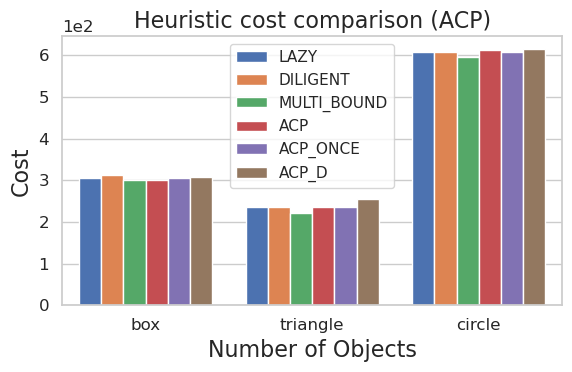

In [6]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res, x="problem", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Heuristic cost comparison (ACP)")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

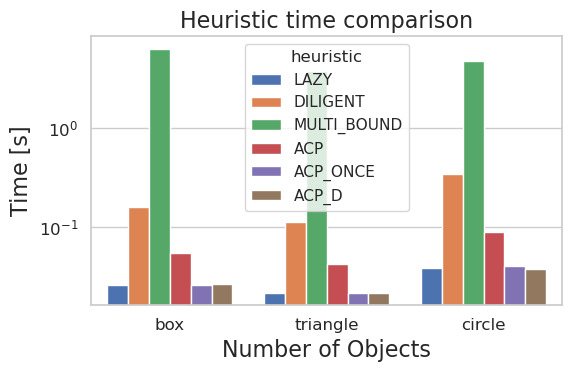

In [7]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res, x="problem", y="time_taken", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time [s]")
ax.set_title("Heuristic time comparison")
ax.set_yscale('log')
plt.tight_layout()
plt.show()

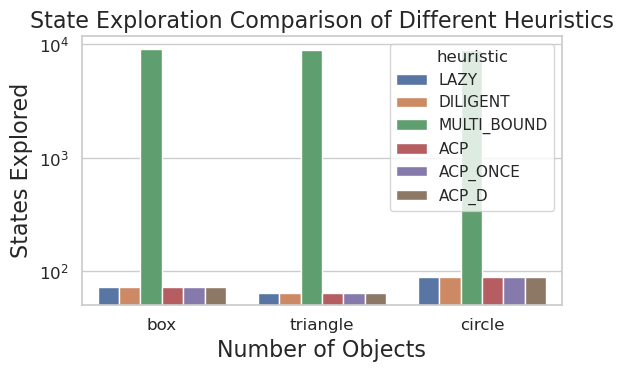

In [8]:
fig, ax = plt.subplots(figsize=figsize)
ax = sns.barplot(data=ppm_res, x="problem", y="states_explored", hue="heuristic", ax=ax)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("States Explored")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_yscale('log')
ax.set_title("State Exploration Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

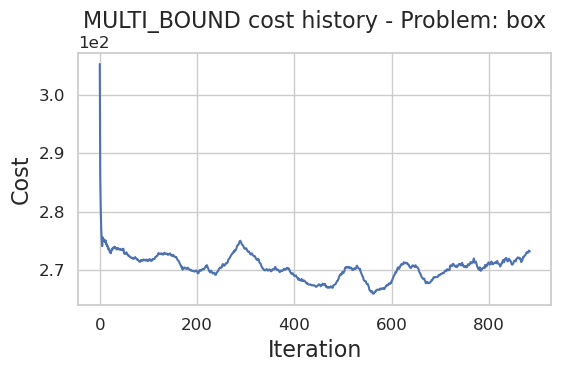

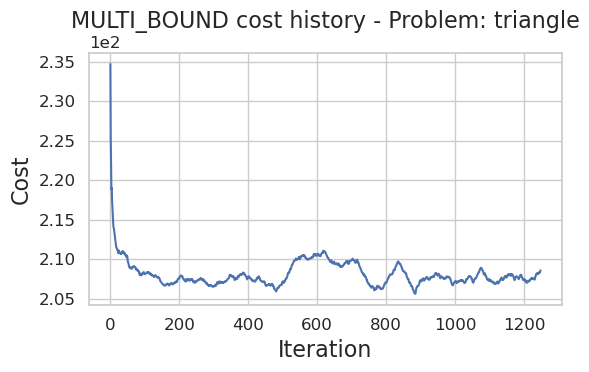

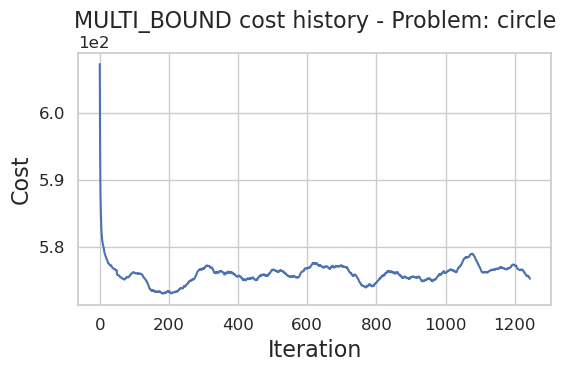

In [9]:
mb_cost_hist_df = pd.read_csv(f"{results_path}/planner_mb_planner_designed_structs_costs.csv")
problems = mb_cost_hist_df['problem'].unique()

window_size = 50
for problem in problems:
    subset = mb_cost_hist_df[(mb_cost_hist_df['problem'] == problem)]
    if subset.empty:
        continue

    subset['smoothed_cost'] = subset['cost'].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).mean()
    )

    plt.figure(figsize=figsize)
    sns.lineplot(data=subset, x="iter", y="smoothed_cost")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.title(f"MULTI_BOUND cost history - Problem: {problem}")
    plt.tight_layout()
    # plt.savefig(f"../../../../../new_plots/mb_costs/mb_cost_history_num_objects_{num_objects}_trial_{trial}.png",
                # bbox_inches='tight', dpi=150)
    plt.show()